<a href="https://colab.research.google.com/github/Yeshwanth369/ML-DL-Projects/blob/main/Classification_with_Custom_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohansacharya/graduate-admissions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'graduate-admissions' dataset.
Path to dataset files: /kaggle/input/graduate-admissions


In [80]:
import torch
import pandas as pd

df = pd.read_csv("/kaggle/input/graduate-admissions/Admission_Predict.csv")

In [81]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [82]:
df.rename(columns={'Chance of Admit ' : 'Admit_Probability'}, inplace=True)
data = df.drop("Serial No.", axis=1)

In [83]:
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admit_Probability
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


<Axes: xlabel='GRE Score', ylabel='TOEFL Score'>

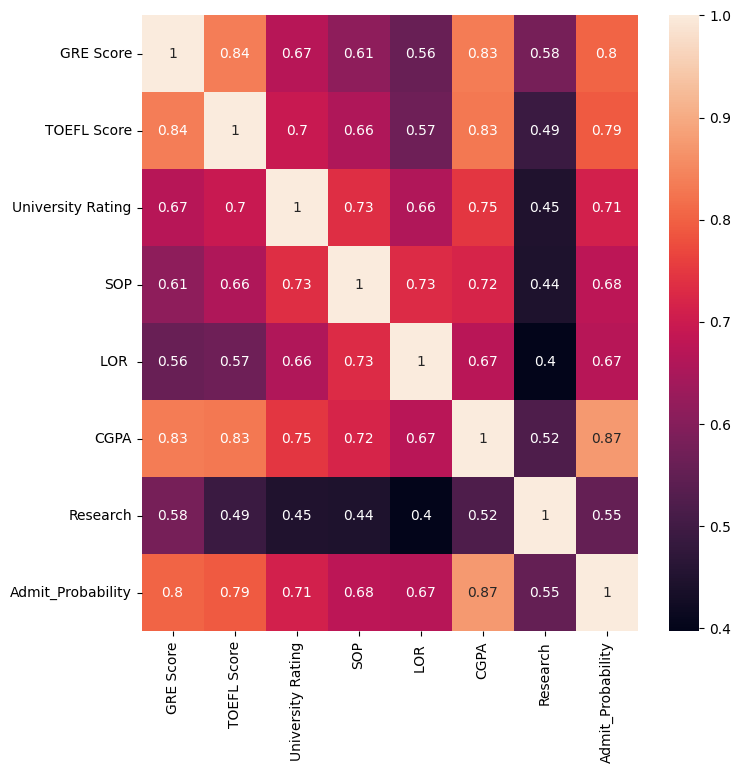

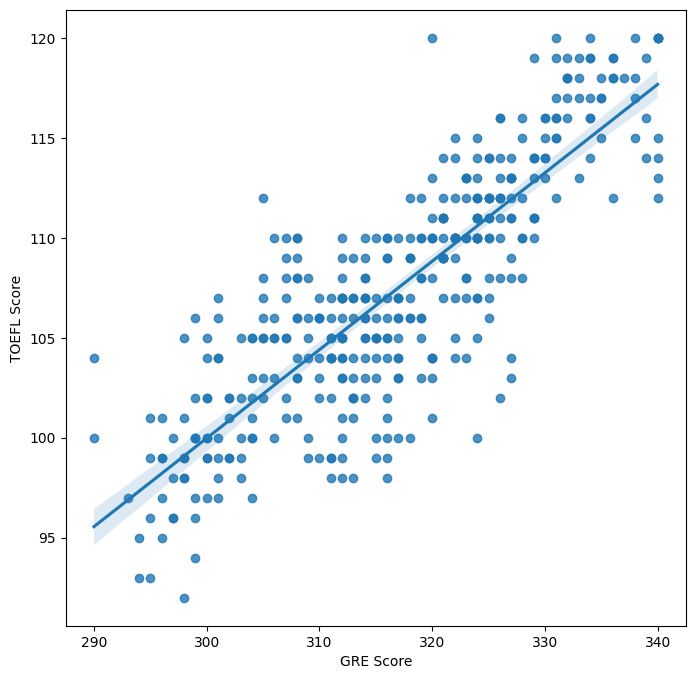

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))
sns.heatmap(data.corr(), annot=True)

plt.figure(figsize=(8,8))
sns.regplot(x = "GRE Score", y = "TOEFL Score", data = data)

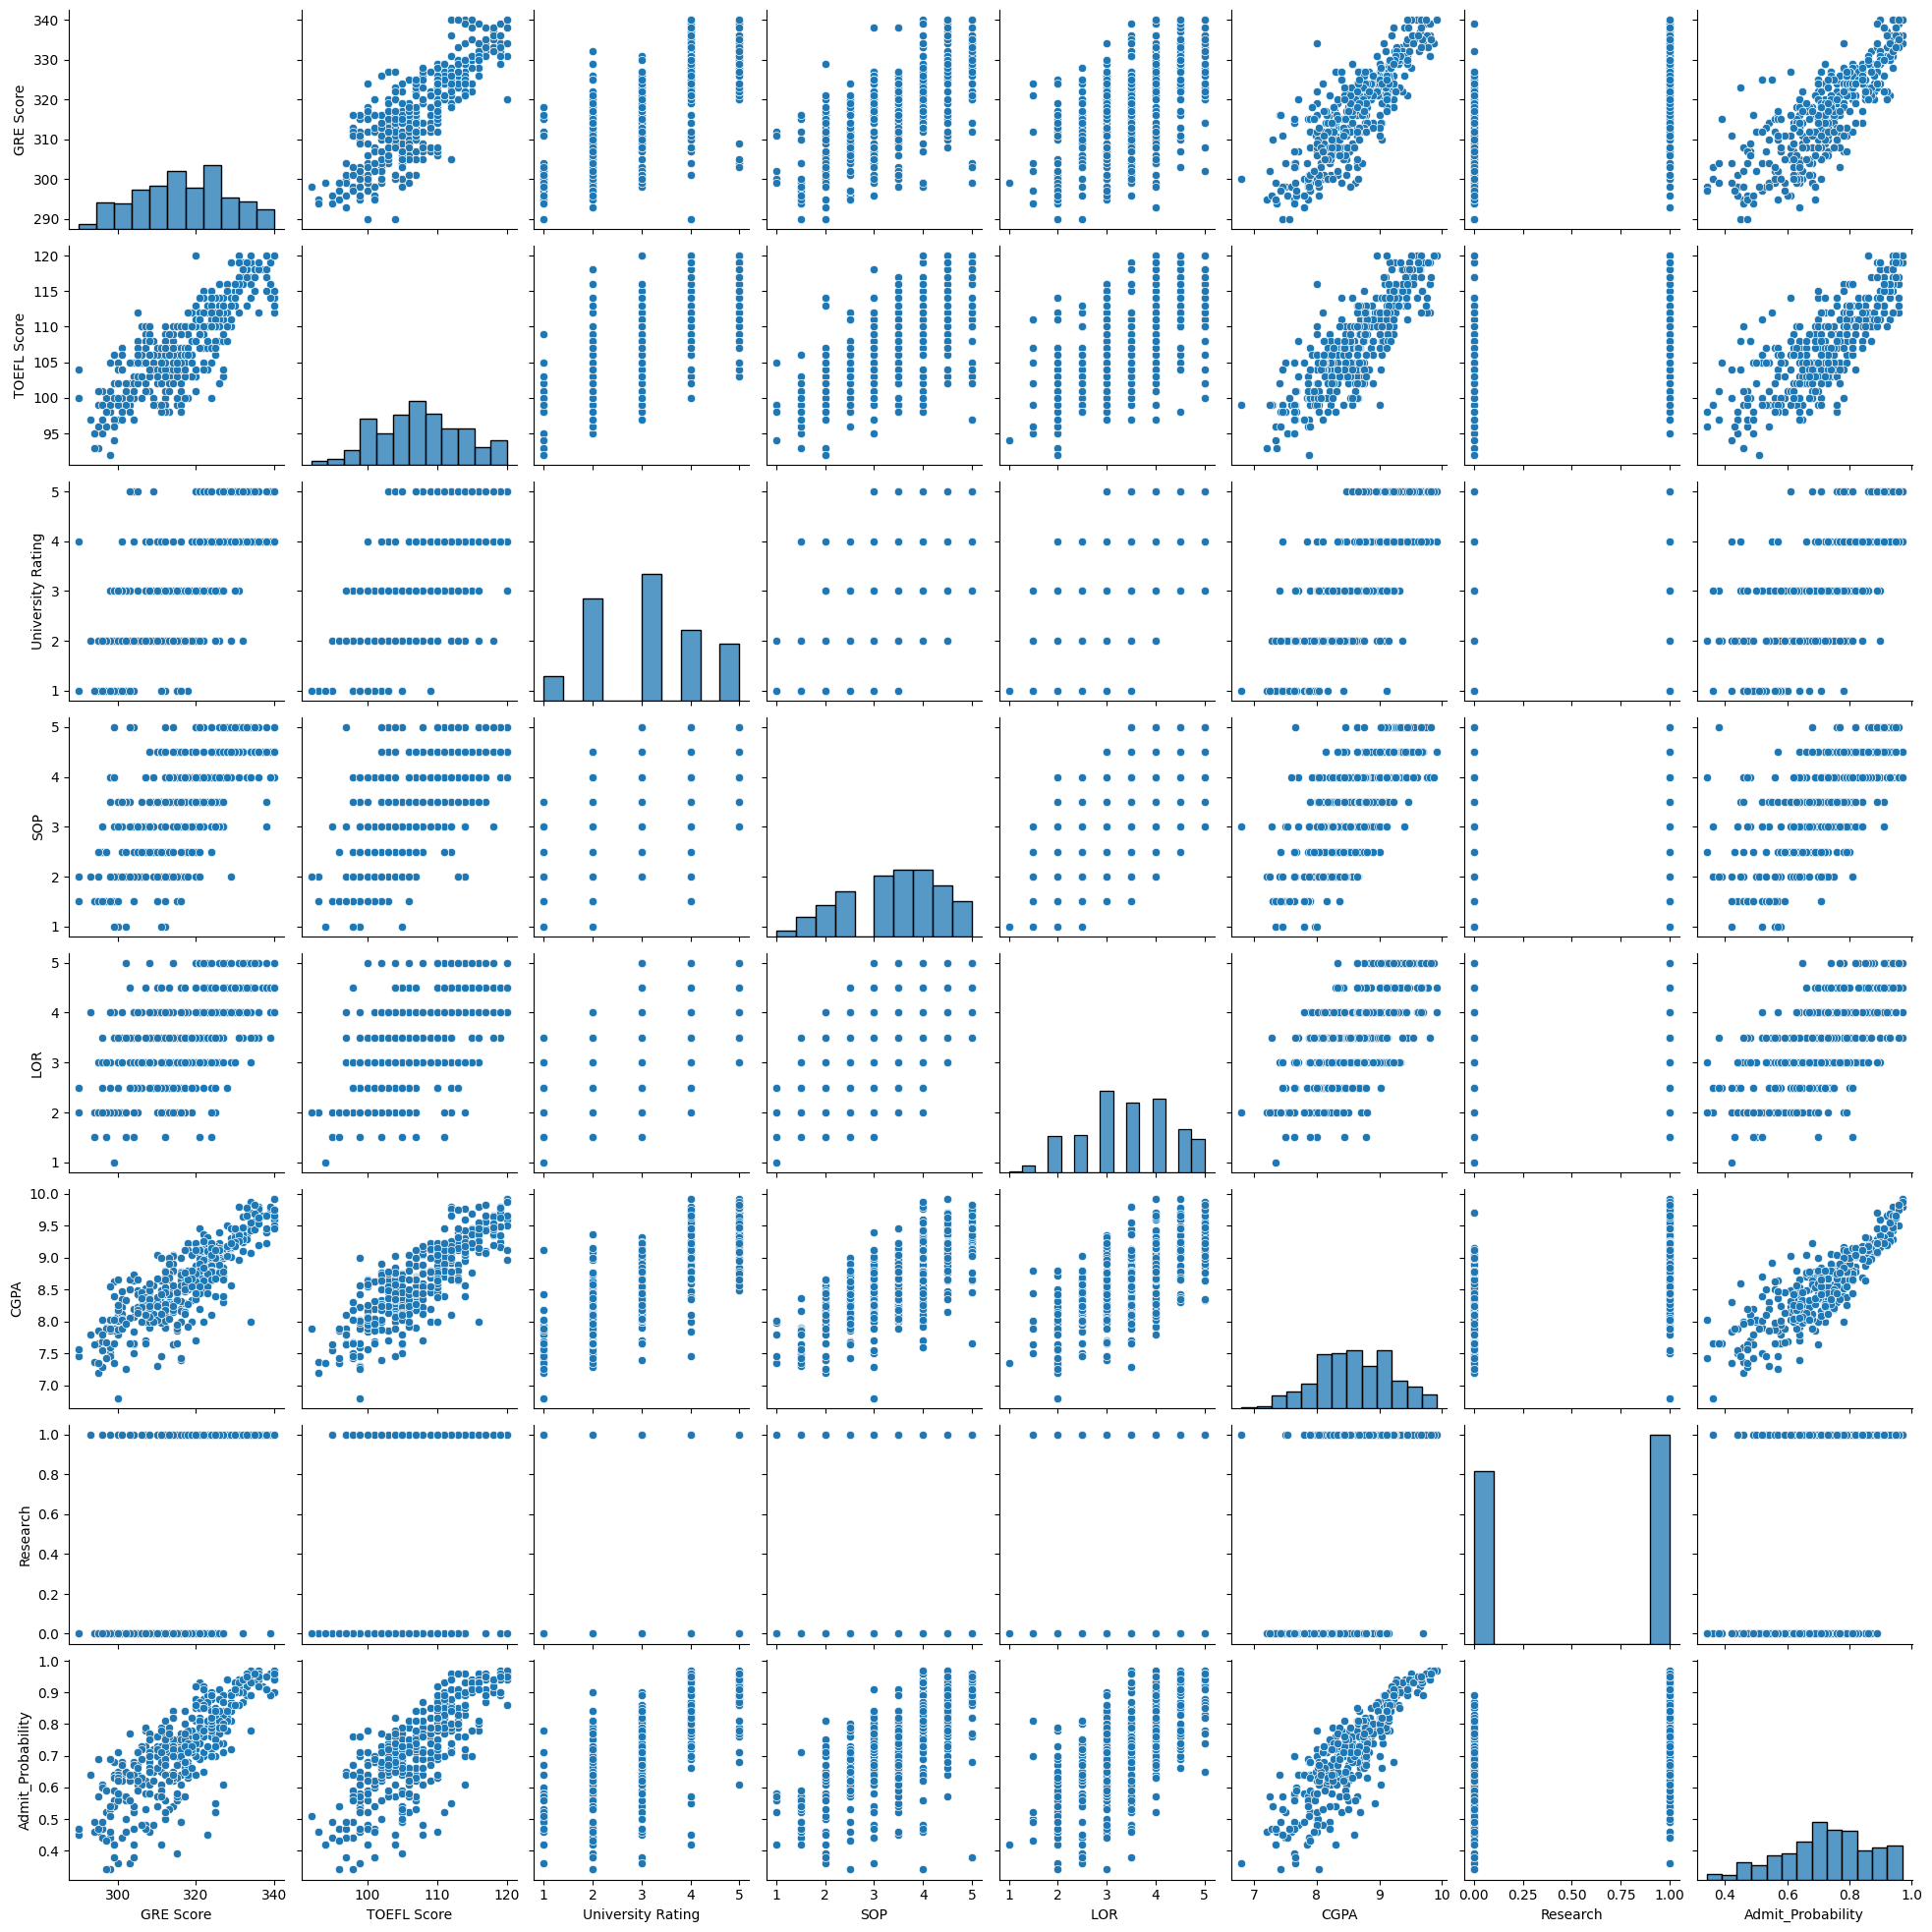

In [85]:
sns.pairplot(data)

In [86]:
data.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Admit_Probability'],
      dtype='object')

In [93]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Admit_Probability,0


In [97]:
df.dtypes

,0
Serial No.,int64
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Admit_Probability,float64


In [89]:
x = data.drop('Admit_Probability',axis=1)
y = data['Admit_Probability']

In [92]:
y_categorized = y.copy() # Work on a copy to avoid SettingWithCopyWarning

y_categorized[y_categorized >= 0.80] = 2
y_categorized[(y_categorized >= 0.60) & (y_categorized < 0.80)] = 1
y_categorized[y_categorized < 0.60] = 0

y = y_categorized # Update the original y with the categorized values

y

,Admit_Probability
0,2.0
1,1.0
2,1.0
3,2.0
4,1.0
...,...
395,2.0
396,2.0
397,2.0
398,1.0


In [99]:
from sklearn.model_selection import train_test_split

x = torch.from_numpy(x.values).float()
y = torch.from_numpy(y.values).long() # Categorical Numbers
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size = 0.8, random_state = 1)

In [104]:
x_train.shape, x_test.shape

(torch.Size([320, 7]), torch.Size([80, 7]))

In [105]:
df.shape

(400, 9)

In [103]:
y_train.shape, y_test.shape

(torch.Size([320]), torch.Size([80]))

In [106]:
import torch.nn as nn

In [107]:
import torch.nn.functional as F # for the GRANULAR control

In [108]:
input_size = x_train.shape[1]
output_size = len(y.unique())

In [113]:
class Net(nn.Module):
  def __init__(self, hidden_size, activation_fn = "relu", apply_dropout = False):
    super(Net,self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, hidden_size)
    self.fc3 = nn.Linear(hidden_size, output_size)

    self.hidden_size = hidden_size
    self.activation_fn = activation_fn

    self.dropout = None
    if apply_dropout :
      self.dropout = nn.Dropout(0.2)


  #- When you call model(x), PyTorch’s nn.Module.__call__() automatically invokes your forward().


  def forward(self,x):
    activation_fn = None
    if self.activation_fn == 'sigmoid':
      activation_fn = F.sigmoid
    elif self.activation_fn == 'tanh':
      activaton_fn = F.tanh
    elif self.activation_fn == 'relu':
      activation_fn = F.relu

    x = activation_fn(self.fc1(x))
    x = activation_fn(self.fc2(x))

    if self.dropout != None :
      x = self.dropout(x)

    x = self.fc3(x)
    return F.log_softmax(x,dim = -1)


In [125]:
def train_and_evaluate_model(model, learn_rate = 0.001, epochs=1000):
  epoch_data = []
  epochs = epochs+1
  optimizer = torch.optim.Adam(model.parameters(), lr = learn_rate)
  loss = nn.NLLLoss()

  test_accuracy = 0

  for epoch in range(epochs):
    optimizer.zero_grad()

    model.train()
    y_pred = model(x_train)

    loss_value = loss(y_pred,y_train)
    loss_value.backward()
    optimizer.step()

    model.eval()

    ypred_test = model(x_test)
    loss_test = loss(ypred_test,y_test)
    _,pred_test = torch.max(ypred_test,1) # Calculating the probability of the max class
    test_accuracy = torch.sum(pred_test == y_test).float() / y_test.shape[0]

    epoch_data.append([epoch,loss_value.data.item(),loss_test.data.item(),test_accuracy])

    if epoch%100 == 0:
      print(f"Epoch : {epoch}, Loss : {loss_value.data.item()
      }",)


  return {
        "model" : model,
        "epoch_data" : epoch_data,
        "test_accuracy" : test_accuracy,
        "Loss_test" : loss_test.data.item(),
        "Loss_train" : loss_value.data.item()
    }


In [124]:

model = Net(hidden_size=1000, apply_dropout=True)
model_data = train_and_evaluate_model(model)

Epoch : 0, Loss : 12.128861427307129
Epoch : 100, Loss : 0.9210293889045715
Epoch : 200, Loss : 0.8291547894477844
Epoch : 300, Loss : 0.7283183336257935
Epoch : 400, Loss : 0.70460045337677
Epoch : 500, Loss : 0.6485806703567505
Epoch : 600, Loss : 0.640508770942688
Epoch : 700, Loss : 0.6382278203964233
Epoch : 800, Loss : 0.6172088384628296
Epoch : 900, Loss : 0.6407440900802612
Epoch : 1000, Loss : 0.6183803677558899


In [129]:
print(model_data["model"])

Net(
  (fc1): Linear(in_features=7, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=1000, bias=True)
  (fc3): Linear(in_features=1000, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


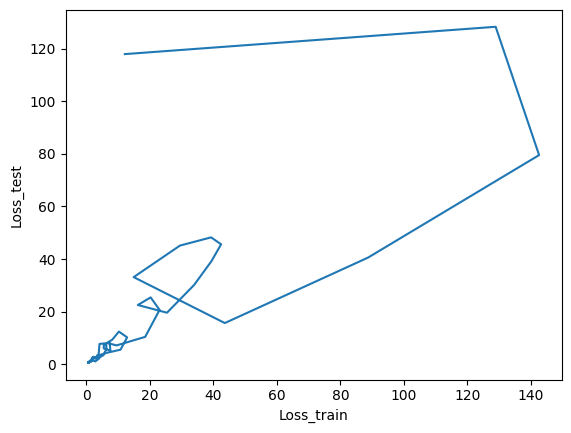

In [131]:
df_epochs_data = pd.DataFrame(model_data["epoch_data"],columns=["Epoch","Loss_train","Loss_test","Test_accuracy"])

plt.plot(df_epochs_data["Loss_train"],df_epochs_data["Loss_test"])
plt.xlabel("Loss_train")
plt.ylabel("Loss_test")
plt.show()

Text(0, 0.5, 'Test_accuracy')

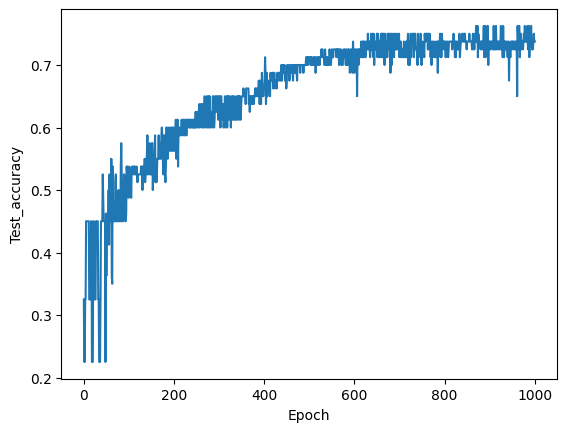

In [133]:
plt.plot(df_epochs_data["Test_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Test_accuracy")

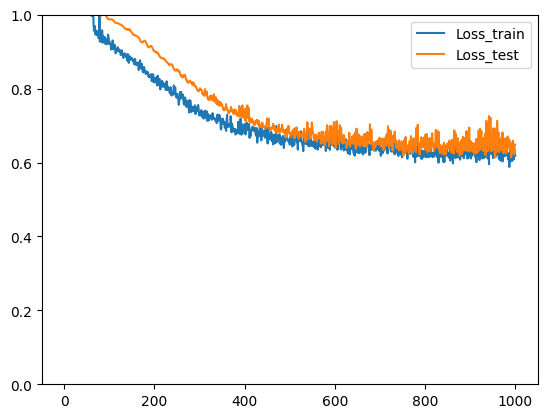

In [140]:
df_epochs_data[["Loss_train","Loss_test"]].plot()
plt.ylim(0,1)
plt.show()